# **Regression Project: Boston House Price Prediction**<a href="#Regression-Project:-Boston-House-Price-Prediction"
class="anchor-link">¶</a>

------------------------------------------------------------------------

## **Objective**<a href="#Objective" class="anchor-link">¶</a>

------------------------------------------------------------------------

Problem Definition and Research Framing

The problem at hand is to **predict the housing prices of a town or a
suburb based on the features of the locality provided to us**. In the
process, we need to **identify the most important features affecting the
price of the house**. We need to employ techniques of data preprocessing
and build a linear regression model that predicts the prices for the
unseen data.

## **Introduction**<a href="#Introduction" class="anchor-link">¶</a>

Housing is one of the most essential components of our wellbeing. Along
with food, water, and a sense of security. Housing is also an indicator
of wealth, social and economic health for a both the individual and the
social system. It affects stability, investment flows, and regional
development.

Housing prices are shaped by a complex system of enviromental,
structural, and socioeconomic factors. Factors would include age of
house, number of rooms, pollution and industrial activity. This owuld
also include school quality, crime rates, and neighborhood disadvantage.

Predictive modeling of houseing prices offer practical value for
stakeholders like homebuyers, developers, and investors. Models can also
provide insight into how different factors interact and shape economic
outcomes.

------------------------------------------------------------------------

## **Dataset**<a href="#Dataset" class="anchor-link">¶</a>

------------------------------------------------------------------------

Each record in the database describes a house in Boston suburb or town.
The data was drawn from the Boston Standard Metropolitan Statistical
Area (SMSA) in 1970. Detailed attribute information can be found below:

Attribute Information:

-   **CRIM:** Per capita crime rate by town
-   **ZN:** Proportion of residential land zoned for lots over 25,000
    sq.ft.
-   **INDUS:** Proportion of non-retail business acres per town
-   **CHAS:** Charles River dummy variable (= 1 if tract bounds river; 0
    otherwise)
-   **NOX:** Nitric Oxide concentration (parts per 10 million)
-   **RM:** The average number of rooms per dwelling
-   **AGE:** Proportion of owner-occupied units built before 1940
-   **DIS:** Weighted distances to five Boston employment centers
-   **RAD:** Index of accessibility to radial highways
-   **TAX:** Full-value property-tax rate per 10,000 dollars
-   **PTRATIO:** Pupil-teacher ratio by town
-   **LSTAT:** % lower status of the population
-   **MEDV:** Median value of owner-occupied homes in 1000 dollars

## **Importing the necessary libraries**<a href="#Importing-the-necessary-libraries" class="anchor-link">¶</a>

In \[214\]:

    # Data manipulation and Visualization
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Modeling and Processing
    from sklearn.model_selection import train_test_split, cross_val_score, KFold
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import (
        r2_score,
        mean_squared_error,
        mean_absolute_error,
        mean_absolute_percentage_error,)

    # Statistical Diagnostic
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.stats.diagnostic import het_breuschpagan
    from scipy import stats

    import warnings
    warnings.filterwarnings("ignore")

    sns.set_theme(style="whitegrid")
    np.random.seed(42)

    # Model Build Linear Regression
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    # Random Forrest
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.model_selection import GridSearchCV

    # Gradient Boosting
    from sklearn.ensemble import GradientBoostingRegressor

    # SHAPE Explainability
    import shap
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler

    # HTML Export
    import subprocess

Importing packages for data manipulation, visualization, modeling,
processing and statistical diagnostic. Also importing packages for
building a linear regression and random forrest model.

### Loading the dataset<a href="#Loading-the-dataset" class="anchor-link">¶</a>

In \[215\]:

    from google.colab import drive
    drive.mount('/content/drive') # Mounting Drive

    Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

In \[216\]:

    train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Boston.csv') # Reading in .csv file

In \[217\]:

    data = train_df.copy() # Making a copy of the dataset

Mounting the Google Drive to make to files easier. Reading in the
dataset and making a copy so no changes occur to original data set.

## Data Overview<a href="#Data-Overview" class="anchor-link">¶</a>

In \[218\]:

    data.head() # Showing the first 5 rows

Out\[218\]:

|     | CRIM    | ZN   | INDUS | CHAS | NOX   | RM    | AGE  | DIS    | RAD | TAX | PTRATIO | LSTAT | MEDV |
|-----|---------|------|-------|------|-------|-------|------|--------|-----|-----|---------|-------|------|
| 0   | 0.00632 | 18.0 | 2.31  | 0    | 0.538 | 6.575 | 65.2 | 4.0900 | 1   | 296 | 15.3    | 4.98  | 24.0 |
| 1   | 0.02731 | 0.0  | 7.07  | 0    | 0.469 | 6.421 | 78.9 | 4.9671 | 2   | 242 | 17.8    | 9.14  | 21.6 |
| 2   | 0.02729 | 0.0  | 7.07  | 0    | 0.469 | 7.185 | 61.1 | 4.9671 | 2   | 242 | 17.8    | 4.03  | 34.7 |
| 3   | 0.03237 | 0.0  | 2.18  | 0    | 0.458 | 6.998 | 45.8 | 6.0622 | 3   | 222 | 18.7    | 2.94  | 33.4 |
| 4   | 0.06905 | 0.0  | 2.18  | 0    | 0.458 | 7.147 | 54.2 | 6.0622 | 3   | 222 | 18.7    | 5.33  | 36.2 |



Checking the first 5 rows of the dataset. Rows 0-4.

In \[219\]:

    data.tail() # Showing the last 5 rows

Out\[219\]:

|     | CRIM    | ZN  | INDUS | CHAS | NOX   | RM    | AGE  | DIS    | RAD | TAX | PTRATIO | LSTAT | MEDV |
|-----|---------|-----|-------|------|-------|-------|------|--------|-----|-----|---------|-------|------|
| 501 | 0.06263 | 0.0 | 11.93 | 0    | 0.573 | 6.593 | 69.1 | 2.4786 | 1   | 273 | 21.0    | 9.67  | 22.4 |
| 502 | 0.04527 | 0.0 | 11.93 | 0    | 0.573 | 6.120 | 76.7 | 2.2875 | 1   | 273 | 21.0    | 9.08  | 20.6 |
| 503 | 0.06076 | 0.0 | 11.93 | 0    | 0.573 | 6.976 | 91.0 | 2.1675 | 1   | 273 | 21.0    | 5.64  | 23.9 |
| 504 | 0.10959 | 0.0 | 11.93 | 0    | 0.573 | 6.794 | 89.3 | 2.3889 | 1   | 273 | 21.0    | 6.48  | 22.0 |
| 505 | 0.04741 | 0.0 | 11.93 | 0    | 0.573 | 6.030 | 80.8 | 2.5050 | 1   | 273 | 21.0    | 7.88  | 11.9 |



Checking the last 5 rows of the dataset. Rows 501-505.

In \[220\]:

    print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.") # Showing the shape of the data

    There are 506 rows and 13 columns.

Checking the number of rows and columns to get an idea of the size and
shape of the dataset.

In \[221\]:

    data.info() # Showing information of the dataset

    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 506 entries, 0 to 505
    Data columns (total 13 columns):
     #   Column   Non-Null Count  Dtype  
    ---  ------   --------------  -----  
     0   CRIM     506 non-null    float64
     1   ZN       506 non-null    float64
     2   INDUS    506 non-null    float64
     3   CHAS     506 non-null    int64  
     4   NOX      506 non-null    float64
     5   RM       506 non-null    float64
     6   AGE      506 non-null    float64
     7   DIS      506 non-null    float64
     8   RAD      506 non-null    int64  
     9   TAX      506 non-null    int64  
     10  PTRATIO  506 non-null    float64
     11  LSTAT    506 non-null    float64
     12  MEDV     506 non-null    float64
    dtypes: float64(10), int64(3)
    memory usage: 51.5 KB

Gathering information about the dataset to see the data types, memory
usuage, range index, column labels and number of cells in each column.

In \[222\]:

    data.isnull().sum() # Looking for missing data

Out\[222\]:

|         | 0   |
|---------|-----|
| CRIM    | 0   |
| ZN      | 0   |
| INDUS   | 0   |
| CHAS    | 0   |
| NOX     | 0   |
| RM      | 0   |
| AGE     | 0   |
| DIS     | 0   |
| RAD     | 0   |
| TAX     | 0   |
| PTRATIO | 0   |
| LSTAT   | 0   |
| MEDV    | 0   |

  
**dtype:** int64

Checking for missing data in each column. There are no missing data.

In \[223\]:

    data.duplicated().sum() # Checking for duplicated rows

Out\[223\]:

    np.int64(0)

There are no duplicated rows.

In \[224\]:

    print("Columns:", data.columns.tolist()) # Printing columns
    print("Target variable:", "MEDV") # Setting "MEDV" as the target variable

    Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']
    Target variable: MEDV

Columns: CRIM: Per capita crime rate by town ZN: Proportion of
residential land zoned for lots over 25,000 sq.ft. INDUS: Proportion of
non-retail business acres per town CHAS: Charles River dummy variable (=
1 if tract bounds river; 0 otherwise) NOX: Nitric Oxide concentration
(parts per 10 million) RM: The average number of rooms per dwelling AGE:
Proportion of owner-occupied units built before 1940 DIS: Weighted
distances to five Boston employment centers RAD: Index of accessibility
to radial highways TAX: Full-value property-tax rate per 10,000 dollars
PTRATIO: Pupil-teacher ratio by town LSTAT: % lower status of the
population MEDV: Median value of owner-occupied homes in 1000 dollars

## Exploratory Data Analysis<a href="#Exploratory-Data-Analysis" class="anchor-link">¶</a>

Univariate Analysis

In \[225\]:

    data.describe() # Providing a statistical summary of dataset

Out\[225\]:

|       | CRIM       | ZN         | INDUS      | CHAS       | NOX        | RM         | AGE        | DIS        | RAD        | TAX        | PTRATIO    | LSTAT      | MEDV       |
|-------|------------|------------|------------|------------|------------|------------|------------|------------|------------|------------|------------|------------|------------|
| count | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 | 506.000000 |
| mean  | 3.613524   | 11.363636  | 11.136779  | 0.069170   | 0.554695   | 6.284634   | 68.574901  | 3.795043   | 9.549407   | 408.237154 | 18.455534  | 12.653063  | 22.532806  |
| std   | 8.601545   | 23.322453  | 6.860353   | 0.253994   | 0.115878   | 0.702617   | 28.148861  | 2.105710   | 8.707259   | 168.537116 | 2.164946   | 7.141062   | 9.197104   |
| min   | 0.006320   | 0.000000   | 0.460000   | 0.000000   | 0.385000   | 3.561000   | 2.900000   | 1.129600   | 1.000000   | 187.000000 | 12.600000  | 1.730000   | 5.000000   |
| 25%   | 0.082045   | 0.000000   | 5.190000   | 0.000000   | 0.449000   | 5.885500   | 45.025000  | 2.100175   | 4.000000   | 279.000000 | 17.400000  | 6.950000   | 17.025000  |
| 50%   | 0.256510   | 0.000000   | 9.690000   | 0.000000   | 0.538000   | 6.208500   | 77.500000  | 3.207450   | 5.000000   | 330.000000 | 19.050000  | 11.360000  | 21.200000  |
| 75%   | 3.677083   | 12.500000  | 18.100000  | 0.000000   | 0.624000   | 6.623500   | 94.075000  | 5.188425   | 24.000000  | 666.000000 | 20.200000  | 16.955000  | 25.000000  |
| max   | 88.976200  | 100.000000 | 27.740000  | 1.000000   | 0.871000   | 8.780000   | 100.000000 | 12.126500  | 24.000000  | 711.000000 | 22.000000  | 37.970000  | 50.000000  |



MEDV has a ceiling effect of 50. CRIM, TAX, and LSTAT have a wide
spread. Some variables are skewed.

In \[226\]:

    data.hist(figsize=(14,10), bins=25) # Plotting histogram and setting overall size of the figure (bins = number of bars, which is the number of intervals)
    plt.tight_layout() # Adjusting subplot spacing so there is no label overlap
    plt.show() # Render plot

![No description has been provided for this
image](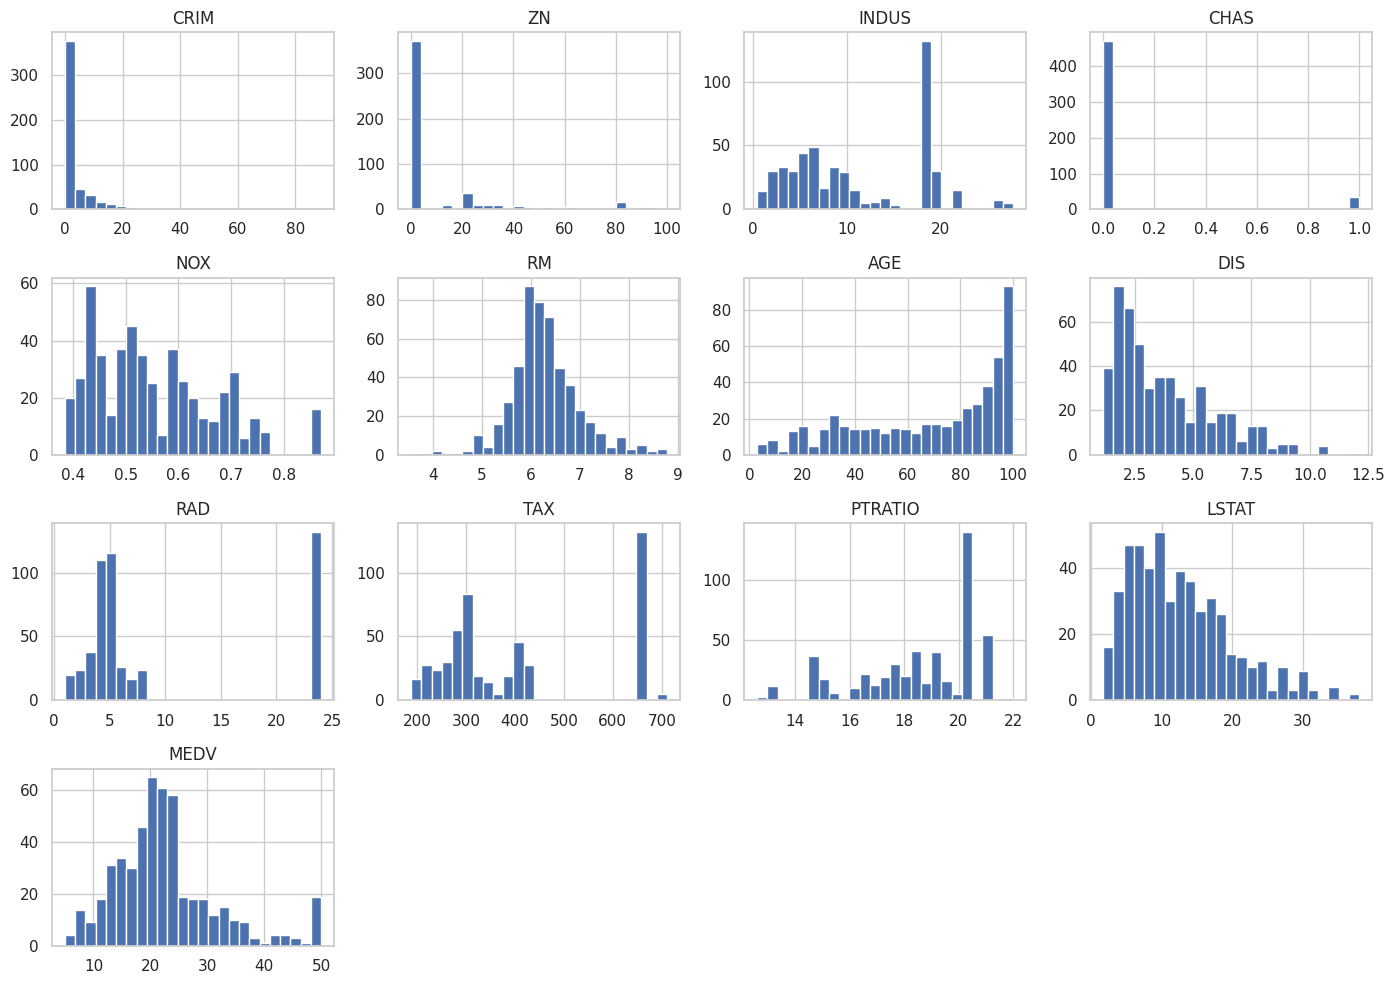%0A)

The univariate distributions show several predictors as right skewed.
More notably CRIM, TAX, and LSTAT predictors. This suggests extreme
values and uneven distributions.

In \[227\]:

    plt.figure(figsize=(8,5)) # Creating a plot canvas with specified dimensions
    sns.histplot(data["MEDV"], bins=30, kde=True) # Plotting histogram of "MEDV" with density curve showing distribution shape
    plt.title("Distribution of MEDV") # Adding title
    plt.show() # Rendering plot

![No description has been provided for this
image](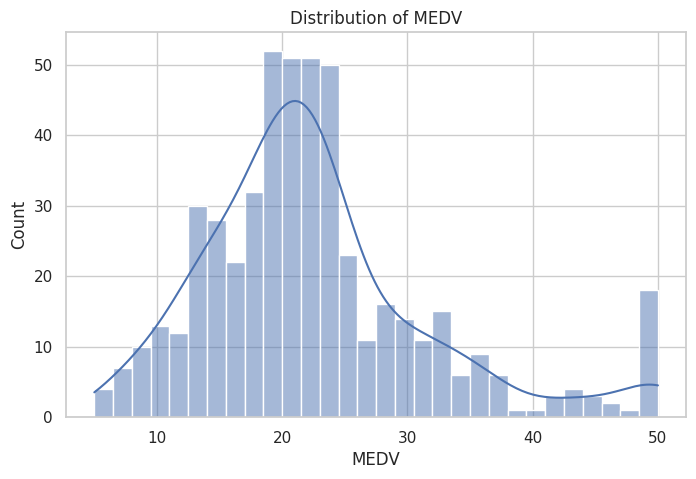%0A)

The MEDV distribution is moderately skewed and shows a ceiling effect at
50. This suggests high value homes are top coded.

In \[228\]:

    plt.figure(figsize=(14,6)) # Creating plot canvas with wide layouit
    sns.boxplot(data=data, orient="h") # Creating boxplots showing outliers
    plt.title("Boxplots of Variables") # Adding title
    plt.show() # Rendering plot

![No description has been provided for this
image](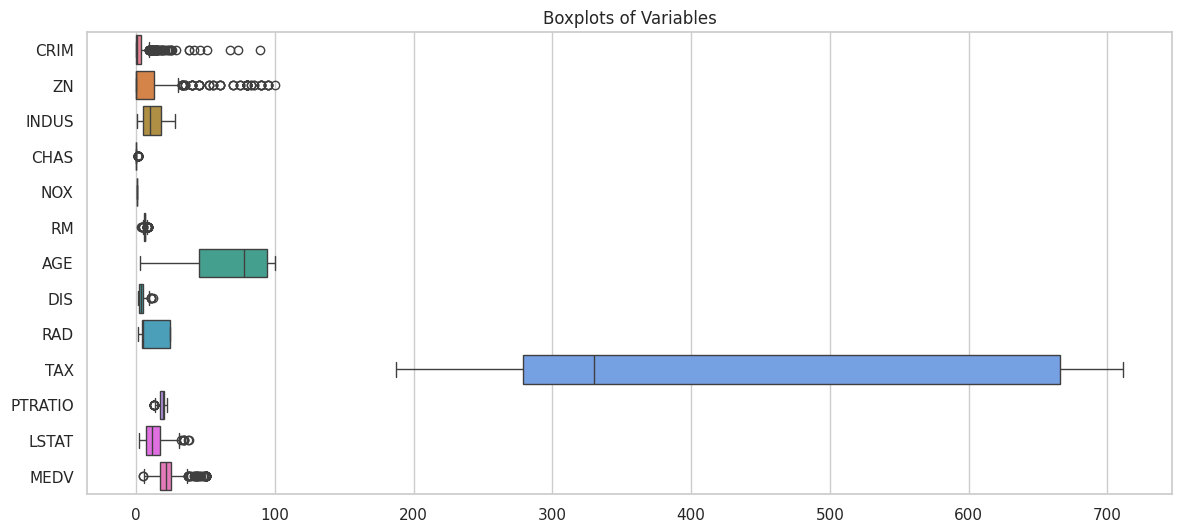%0A)

Several variable contain outliers, particularily CRIM, TAX, and LSTAT.

Bivariate Analysis

In \[229\]:

    corr_target = data.corr(numeric_only=True)["MEDV"].sort_values(ascending=False) # Copmuting correlations and extracting target variable
    corr_target # Rendering sorted correlations

Out\[229\]:

|         | MEDV      |
|---------|-----------|
| MEDV    | 1.000000  |
| RM      | 0.695360  |
| ZN      | 0.360445  |
| DIS     | 0.249929  |
| CHAS    | 0.175260  |
| AGE     | -0.376955 |
| RAD     | -0.381626 |
| CRIM    | -0.388305 |
| NOX     | -0.427321 |
| TAX     | -0.468536 |
| INDUS   | -0.483725 |
| PTRATIO | -0.507787 |
| LSTAT   | -0.737663 |

  
**dtype:** float64

RM shows the strongest positive correlation with the housing price. The
LSTAT variable shows the strongest negative correlation. This suggests
that larger homes tend to be more valuable and sociological disadvantage
is strongly associated with lower housing values.

In \[230\]:

    plt.figure(figsize=(10,8)) # Creating figure
    sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0) # Creating heatmap of correlation matrix and puting correlations using a color gradient
    plt.title("Correlation Heatmap") # Creating title
    plt.show() # Rendering plot

![No description has been provided for this
image](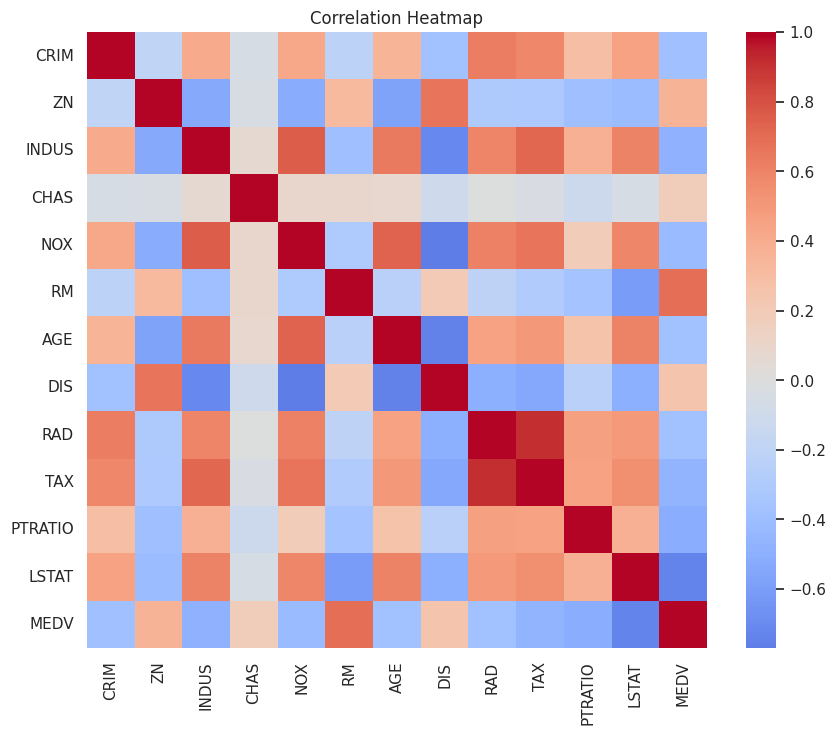%0A)

The heatmap shows and confirms strong relationships between several
predictors and the target variable MEDV. It shows some predictors are
highly correlated with one another. This suggests multicollinearity.

In \[231\]:

    features = ["RM", "LSTAT", "PTRATIO", "NOX", "CRIM", "DIS"] # List of selected features

    fig, axes = plt.subplots(2, 3, figsize=(15,9)) # Creating subplots and setting overall size of figure
    axes = axes.flatten() # Flatten 2D array of axes into a 1D array

    for ax, col in zip(axes, features): # Loop through each axis with corresponding feature
        sns.regplot(data=data, x=col, y="MEDV", ax=ax, scatter_kws={"alpha":0.6}) # Creating a regression plot for each feature against MEDV
        ax.set_title(f"{col} vs MEDV") # Creating titles

    plt.tight_layout() # Adjusting space between subpolts to prevent overlap
    plt.show() # Rendering plots

![No description has been provided for this
image](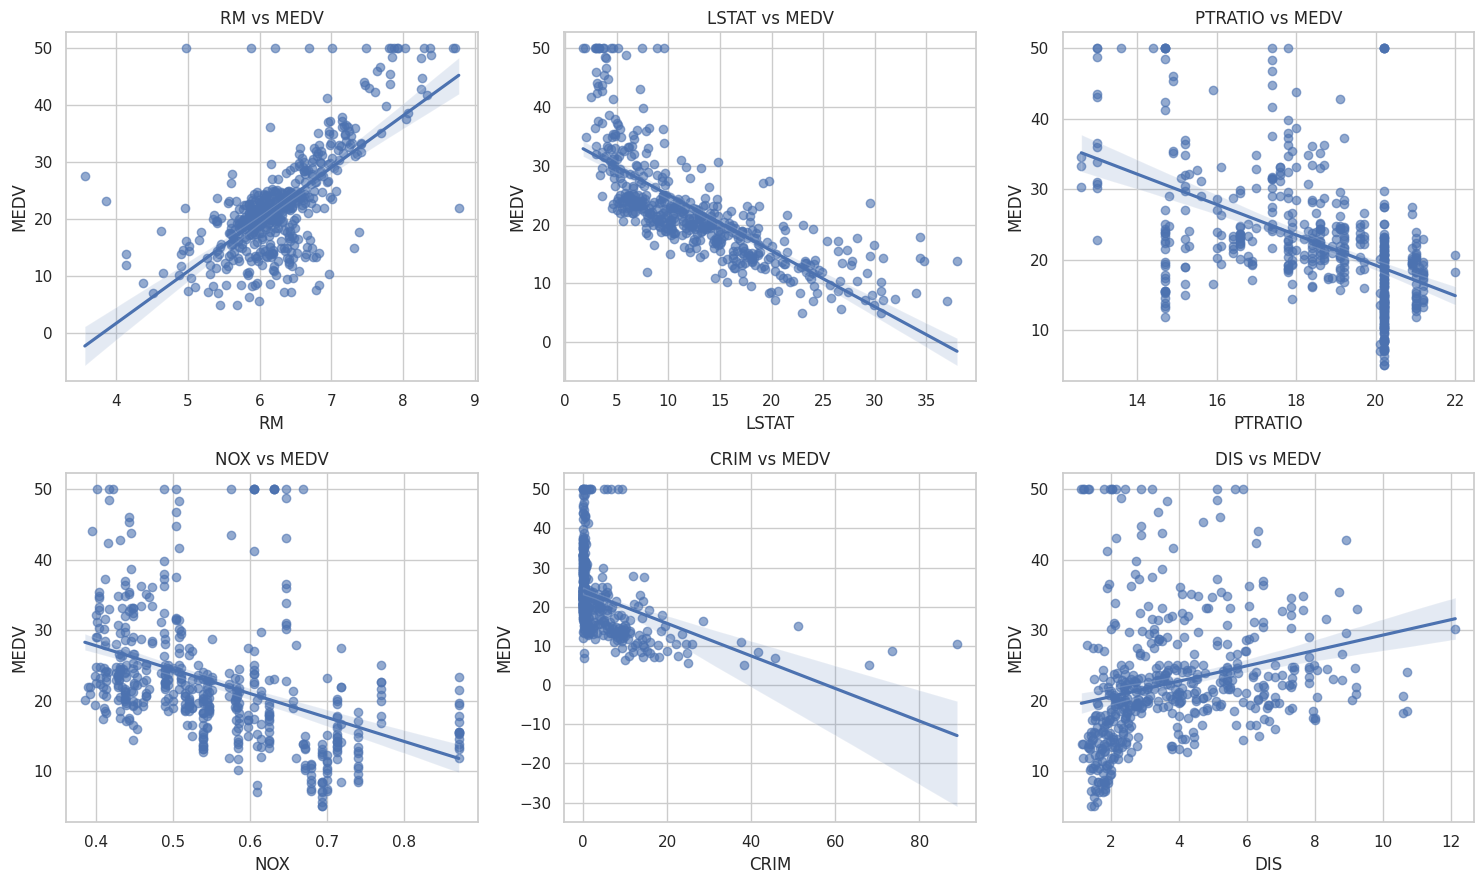%0A)

The regression plot confirms that the housing price rises with room
count and falls with increasing socioeconomic disadvantage, crime,
pollution and weaker school related conditions, suggesting dependancy on
structural and neighborhood factors.

## Data Preprocessing<a href="#Data-Preprocessing" class="anchor-link">¶</a>

In \[232\]:

    X = data.drop("MEDV", axis=1) # Dropping "MEDV" from the dataset
    y = data["MEDV"] # Setting "MEDV" on the Y axis

Removing MEDV column and seperates dataset into features (x) and the
target variable (y). (x) contains all the housing, enviromental, and
socioeconomic variables (y) contains the median home value.

In \[233\]:

    plt.figure(figsize=(14,6)) # Creating figure specifying width and height
    sns.boxplot(data=data, orient="h") # Note: 'data' must be defined from previous cells
    plt.title("Outlier Detection using Boxplots") # Creating title
    plt.show() # Rendering plot

![No description has been provided for this
image](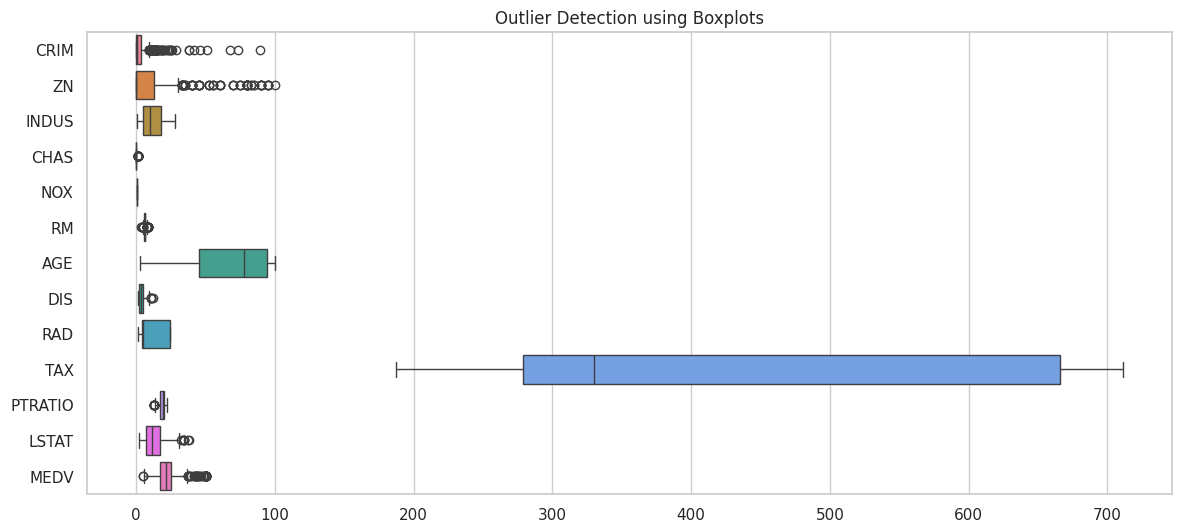%0A)

Outliers are identified using the boxplots in the CRIM, TAX, and LSTAT
variables. Outliers will be kept to represent real world variation to
presearve generalizability.

In \[234\]:

    skewed_cols = ["CRIM", "LSTAT", "TAX"] # Skewed variables

    for col in skewed_cols: # Looping through each column of skewed variables
        X[col] = np.log1p(X[col]) # Applying log transformation
        print(f"{col} skewness: {X[col].skew()}") # Printing skewness of transformed column

    CRIM skewness: 1.2692005882725572
    LSTAT skewness: -0.18719503273600818
    TAX skewness: 0.3317531183612903

To keep the outliers as a natural influence a log transformation on
these variables is applied to reduce influence and improve model
stability.

In \[235\]:

    print("Skewness after transformation:") # Printing title
    print(X[skewed_cols].skew()) # Calculating and displaying skewness

    Skewness after transformation:
    CRIM     1.269201
    LSTAT   -0.187195
    TAX      0.331753
    dtype: float64

Skewness evaluated and the results show a significant reduction in
skewness.

In \[236\]:

    y_log = np.log1p(y) # Adds 1 to every value and applying a naural log to reduce skew

A log transformation was applied to the target variable to reduce
skewness and improve performance.

In \[237\]:

    X_train, X_test, y_train, y_test = train_test_split( # x= features, y_log= transformed target variable
        X, y_log, test_size=0.2, random_state=42 # 20% of data goes to test set, 80% to training set and fixes randomness so results are reproducible
    )

The dataset was split into training and test sets to be evaluated on
unseen data.

## Interaction Effects<a href="#Interaction-Effects" class="anchor-link">¶</a>

In \[238\]:

    X_interact = X.copy() # Making a copy
    X_interact["RM_LSTAT"] = X_interact["RM"] * X_interact["LSTAT"] # Interaction between number of rooms and socioeconomic disadvantage
    X_interact["NOX_CRIM"] = X_interact["NOX"] * X_interact["CRIM"] # Interaction between pollution and crime
    X_interact["RM_PTRATIO"] = X_interact["RM"] * X_interact["PTRATIO"] # Interaction between rooms and pupil-teacher ration
    X_interact.head() # Checking first 5 rows

Out\[238\]:

|     | CRIM     | ZN   | INDUS | CHAS | NOX   | RM    | AGE  | DIS    | RAD | TAX      | PTRATIO | LSTAT    | RM_LSTAT  | NOX_CRIM | RM_PTRATIO |
|-----|----------|------|-------|------|-------|-------|------|--------|-----|----------|---------|----------|-----------|----------|------------|
| 0   | 0.006300 | 18.0 | 2.31  | 0    | 0.538 | 6.575 | 65.2 | 4.0900 | 1   | 5.693732 | 15.3    | 1.788421 | 11.758865 | 0.003389 | 100.5975   |
| 1   | 0.026944 | 0.0  | 7.07  | 0    | 0.469 | 6.421 | 78.9 | 4.9671 | 2   | 5.493061 | 17.8    | 2.316488 | 14.874169 | 0.012637 | 114.2938   |
| 2   | 0.026924 | 0.0  | 7.07  | 0    | 0.469 | 7.185 | 61.1 | 4.9671 | 2   | 5.493061 | 17.8    | 1.615420 | 11.606793 | 0.012627 | 127.8930   |
| 3   | 0.031857 | 0.0  | 2.18  | 0    | 0.458 | 6.998 | 45.8 | 6.0622 | 3   | 5.407172 | 18.7    | 1.371181 | 9.595523  | 0.014591 | 130.8626   |
| 4   | 0.066770 | 0.0  | 2.18  | 0    | 0.458 | 7.147 | 54.2 | 6.0622 | 3   | 5.407172 | 18.7    | 1.845300 | 13.188361 | 0.030581 | 133.6489   |



Interaction effects appear to improve performance with better R^2, RMSE,
MAE and MAPE.

In \[239\]:

    X_train_int, X_test_int, y_train_int, y_test_int = train_test_split( # Splitting dataset into training and testing sets
        X_interact, # Feature matrix
        y_log, # Target variable
        test_size=0.2, # 20% of data is researved for testing
        random_state=42 # Reproducibility
    )

Dataset is split into training and testing sets using a 80/20 split.
Target variable was log transformed.

In \[240\]:

    lr_interact = Pipeline([ # Creating pipeline
        ("scaler", StandardScaler()), # Standardizes features
        ("model", LinearRegression()) # Fitting linear relationship between features and target
    ])

    lr_interact.fit(X_train_int, y_train_int) # Fitting the model on training data with interaction features
    lr_interact_pred_log = lr_interact.predict(X_test_int) # Predicting on test data

    y_test_int_actual = np.expm1(y_test_int) # Converting actual values back to original scale
    lr_interact_pred_actual = np.expm1(lr_interact_pred_log) # Converting predicted values back to original scale

    lr_interact_r2 = r2_score(y_test_int_actual, lr_interact_pred_actual) # R^2 proportion of variance explained
    lr_interact_rmse = np.sqrt(mean_squared_error(y_test_int_actual, lr_interact_pred_actual)) # RMSE penalizes large errors more heavily
    lr_interact_mae = mean_absolute_error(y_test_int_actual, lr_interact_pred_actual) # MAE average absolute prediction error
    lr_interact_mape = mean_absolute_percentage_error(y_test_int_actual, lr_interact_pred_actual) * 100 # MAPE average percentage error times 100

    print("Linear Regression with Interactions") # Creating title
    print("R²   :", round(lr_interact_r2, 4)) # Printing R^2 metric
    print("RMSE :", round(lr_interact_rmse, 4)) # Printing RMSE metric
    print("MAE  :", round(lr_interact_mae, 4)) # Printing MAE metric
    print("MAPE :", round(lr_interact_mape, 2), "%") # Printing MAPE metric

    Linear Regression with Interactions
    R²   : 0.7741
    RMSE : 4.07
    MAE  : 2.3563
    MAPE : 11.43 %

Shows improvement over the Linear Regression with a better R^2, lower
RMSE, MAE, and MAPE.

## Model Building - Linear Regression<a href="#Model-Building---Linear-Regression" class="anchor-link">¶</a>

In \[241\]:

    lr_final = Pipeline([ # Building a pipeline with scaling and linear regression
        ("scaler", StandardScaler()), # Transforms features
        ("model", LinearRegression()) # Fitting a linear relationship to the target variable
    ])

    lr_final.fit(X_train, y_train) # Fitting the model

Out\[241\]:

    Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

**In a Jupyter environment, please rerun this cell to show the HTML
representation or trust the notebook.  
On GitHub, the HTML representation is unable to render, please try
loading this page with nbviewer.org.**

Pipeline

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.pipeline.Pipeline.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for Pipeline</span></a><span
class="sk-estimator-doc-link fitted">iFitted</span>

    Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

StandardScaler

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.StandardScaler.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for StandardScaler</span></a>

    StandardScaler()

LinearRegression

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LinearRegression.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for LinearRegression</span></a>

    LinearRegression()

Creates the interpretable baseline model.

## Model Performance Check<a href="#Model-Performance-Check" class="anchor-link">¶</a>

In \[242\]:

    lr_pred_log = lr_final.predict(X_test) # Predicting on the log scale

    y_test_actual = np.expm1(y_test) # Converting actual test values back to original scale
    lr_pred_actual = np.expm1(lr_pred_log) # Converting predicted values back to original scal

    lr_r2 = r2_score(y_test_actual, lr_pred_actual) # Calculating R^2
    lr_rmse = np.sqrt(mean_squared_error(y_test_actual, lr_pred_actual)) # Calculating RMSE
    lr_mae = mean_absolute_error(y_test_actual, lr_pred_actual) # Calculating MAE
    lr_mape = mean_absolute_percentage_error(y_test_actual, lr_pred_actual) * 100 # Calculating MAPE

    print("Linear Regression Results") # Printing title
    print("R²   :", round(lr_r2, 4)) # Prinitnig R^2 result
    print("RMSE :", round(lr_rmse, 4)) # Printing RMSE result
    print("MAE  :", round(lr_mae, 4)) # Printing MAE result
    print("MAPE :", round(lr_mape, 2), "%") # Printing MAPE result

    Linear Regression Results
    R²   : 0.757
    RMSE : 4.2217
    MAE  : 2.5244
    MAPE : 12.22 %

The Linear Regression model performs well, expaining roughly 75% of the
variance in housing prices. Though, some prediction error still remains,
suggesting that the linear regression does not fully capture complexity
of the data.

In \[243\]:

    cv_scores = cross_val_score( # Evaluate the linear regression model using cross-validation
        lr_final, # Model pipeline
        X, # predictors
        y_log, # Transformed target
        cv=5, # 5 folds
        scoring="r2" # Using R^2 as the evaluating metric
    )

    print("Cross-Validation R² Scores:", cv_scores) # Printing fold scores
    print("Mean CV R²:", round(cv_scores.mean(), 4)) # Printing mean cross-validation score
    print("Std CV R²:", round(cv_scores.std(), 4)) # Printing variability folds

    Cross-Validation R² Scores: [0.69392812 0.66100635 0.62989081 0.6006195  0.50382086]
    Mean CV R²: 0.6179
    Std CV R²: 0.065

The cross-validation score is lower than the holdout test-set score.
This suggests the model performance varies accross different data
splits, indicating the linear regression may not generalize equally
across the full dataset.

In \[244\]:

    train_pred_log = lr_final.predict(X_train) # Generating predictions on training data
    y_train_actual = np.expm1(y_train) # Converting actual training target values back to original scale
    train_pred_actual = np.expm1(train_pred_log) # Converting predicted values back to original scale

Predictions were generated on the log transformation scale and converted
back to the original scale.

In \[245\]:

    train_r2 = r2_score(y_train_actual, train_pred_actual) # Measures overall fit on training set
    train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred_actual)) # Penalizes large errors
    train_mae = mean_absolute_error(y_train_actual, train_pred_actual) # Average absolute error
    train_mape = mean_absolute_percentage_error(y_train_actual, train_pred_actual) * 100 # Average percentage error times 100

    print("Train R²:", round(train_r2, 4)) # Printing R^2 metric
    print("Train RMSE:", round(train_rmse, 4))  # Printing RMSE metric
    print("Train MAE:", round(train_mae, 4)) # Printing MAE metric
    print("Train MAPE:", round(train_mape, 2), "%") # Printing MAPE metric

    print("Test R²:", round(lr_r2, 4)) # Printing R^2 metric
    print("Test RMSE:", round(lr_rmse, 4)) # Printing RMSE metric
    print("Test MAE:", round(lr_mae, 4)) # Printing MAE metric
    print("Test MAPE:", round(lr_mape, 2), "%") # Printing MAPE metric

    Train R²: 0.7957
    Train RMSE: 4.2124
    Train MAE: 2.9854
    Train MAPE: 13.91 %
    Test R²: 0.757
    Test RMSE: 4.2217
    Test MAE: 2.5244
    Test MAPE: 12.22 %

The test and train R^2 are really close and the MAE/MAPE have a slightly
worse training error after back transformation.

## Checking Linear Regression Assumptions<a href="#Checking-Linear-Regression-Assumptions"
class="anchor-link">¶</a>

In \[246\]:

    X_const = sm.add_constant(X) # Adds intercept to feature matrix
    ols_model = sm.OLS(y, X_const).fit() # Ordinary least squares regression and fitting model using original target y
    print(ols_model.summary()) # Printing full statistical summary of the model

                                OLS Regression Results                            
    ==============================================================================
    Dep. Variable:                   MEDV   R-squared:                       0.782
    Model:                            OLS   Adj. R-squared:                  0.777
    Method:                 Least Squares   F-statistic:                     147.5
    Date:                Tue, 31 Mar 2026   Prob (F-statistic):          1.68e-154
    Time:                        04:38:34   Log-Likelihood:                -1454.7
    No. Observations:                 506   AIC:                             2935.
    Df Residuals:                     493   BIC:                             2990.
    Df Model:                          12                                         
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         83.7546      7.746     10.813      0.000      68.536      98.974
    CRIM          -1.8881      0.524     -3.601      0.000      -2.918      -0.858
    ZN             0.0250      0.012      2.005      0.046       0.001       0.049
    INDUS          0.0225      0.054      0.415      0.679      -0.084       0.129
    CHAS           2.3244      0.789      2.947      0.003       0.775       3.874
    NOX          -13.8242      3.540     -3.905      0.000     -20.779      -6.869
    RM             2.2958      0.399      5.758      0.000       1.512       3.079
    AGE            0.0320      0.012      2.597      0.010       0.008       0.056
    DIS           -1.2080      0.184     -6.580      0.000      -1.569      -0.847
    RAD            0.3440      0.066      5.183      0.000       0.214       0.474
    TAX           -4.3112      1.143     -3.771      0.000      -6.557      -2.065
    PTRATIO       -0.8952      0.120     -7.446      0.000      -1.131      -0.659
    LSTAT        -10.4736      0.650    -16.106      0.000     -11.751      -9.196
    ==============================================================================
    Omnibus:                      144.258   Durbin-Watson:                   1.156
    Prob(Omnibus):                  0.000   Jarque-Bera (JB):              611.644
    Skew:                           1.216   Prob(JB):                    1.52e-133
    Kurtosis:                       7.806   Cond. No.                     3.19e+03
    ==============================================================================

    Notes:
    [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
    [2] The condition number is large, 3.19e+03. This might indicate that there are
    strong multicollinearity or other numerical problems.

Gives regression inference. OLS uses raw y and predictive model uses
y_log.

In \[247\]:

    coef_df = pd.DataFrame({ # Creating DataFrame
        "Feature": X.columns, # Linking feature names
        "Coefficient": lr_final.named_steps["model"].coef_ # Linking coefficients
    })

    coef_df.sort_values("Coefficient", ascending=False) # Sort coefficients from largest to smallest

Out\[247\]:

|     | Feature | Coefficient |
|-----|---------|-------------|
| 8   | RAD     | 0.153757    |
| 5   | RM      | 0.040775    |
| 6   | AGE     | 0.022867    |
| 3   | CHAS    | 0.021928    |
| 2   | INDUS   | 0.014922    |
| 1   | ZN      | 0.002154    |
| 4   | NOX     | -0.052879   |
| 9   | TAX     | -0.060314   |
| 10  | PTRATIO | -0.081868   |
| 7   | DIS     | -0.086696   |
| 0   | CRIM    | -0.187799   |
| 11  | LSTAT   | -0.229232   |



Socioeconomic status is the strongest driver of housing prices, followed
by crime and accessibility factors. Positive contributers are the home
size and proximity to amenities.

In \[248\]:

    vif_df = pd.DataFrame() # Creating empty dataframe to store results
    vif_df["feature"] = X.columns # Adding feature names
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] # looping through feature index i
    vif_df.sort_values("VIF", ascending=False) # Sort features from highest VIF (Worst multicollinearity to lowest)

Out\[248\]:

|     | feature | VIF        |
|-----|---------|------------|
| 9   | TAX     | 484.086770 |
| 5   | RM      | 122.122876 |
| 10  | PTRATIO | 119.471803 |
| 4   | NOX     | 102.607560 |
| 11  | LSTAT   | 66.437926  |
| 6   | AGE     | 22.035671  |
| 7   | DIS     | 16.694741  |
| 8   | RAD     | 14.430256  |
| 0   | CRIM    | 12.568289  |
| 2   | INDUS   | 12.231979  |
| 1   | ZN      | 2.782293   |
| 3   | CHAS    | 1.138977   |



High VIF values indicate predictors have a strong overlap.

In \[249\]:

    residuals = y_test_actual - lr_pred_actual # Computing residuals as actual minus predicted values

    plt.figure(figsize=(6,4)) # Plotting residual distribution
    sns.histplot(residuals, kde=True) # Creating histogram for residual distribution
    plt.title("Residual Distribution - Linear Regression") # Creating title
    plt.show() # Rendering plot

    plt.figure(figsize=(6,5)) # Plotting residual distribution
    plt.scatter(lr_pred_actual, residuals, alpha=0.7) # Creating histogram for residual distribution
    plt.axhline(0, linestyle="--") # Drawing line
    plt.title("Linear Regression Residuals vs Predicted") # Creating title
    plt.xlabel("Predicted") # Creating x label
    plt.ylabel("Residuals") # Creating y label
    plt.show() # Rendering plot

![No description has been provided for this
image](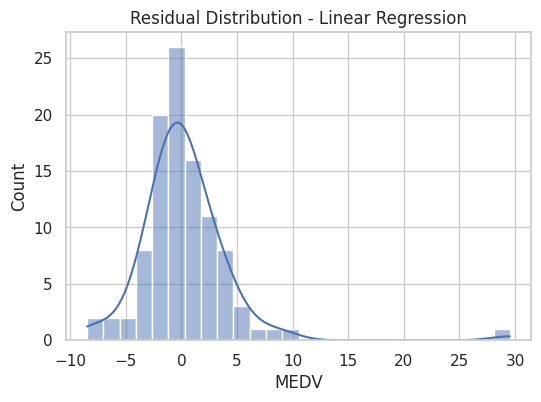%0A)

![No description has been provided for this
image](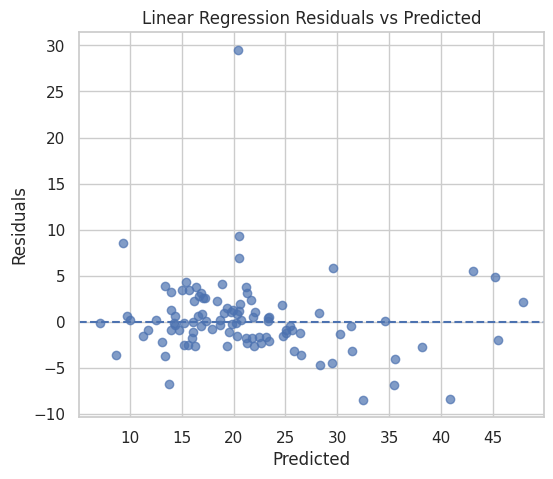%0A)

The patterns suggest missing nonlinear structure.

## Random Forest<a href="#Random-Forest" class="anchor-link">¶</a>

In \[250\]:

    # =========================
    # Baseline Random Forest
    # =========================

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
    import numpy as np

    # Rebuild the true baseline Random Forest model
    rf_baseline = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    # Fit on training data
    rf_baseline.fit(X_train, y_train)

    # Predict on test data
    rf_pred_log = rf_baseline.predict(X_test)

    # Convert predictions and actual values back to original MEDV scale
    y_test_actual = np.expm1(y_test)
    rf_pred_actual = np.expm1(rf_pred_log)

    # Evaluate
    rf_r2 = r2_score(y_test_actual, rf_pred_actual)
    rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred_actual))
    rf_mae = mean_absolute_error(y_test_actual, rf_pred_actual)
    rf_mape = mean_absolute_percentage_error(y_test_actual, rf_pred_actual) * 100

    print("Baseline Random Forest Performance")
    print("R²   :", round(rf_r2, 4))
    print("RMSE :", round(rf_rmse, 4))
    print("MAE  :", round(rf_mae, 4))
    print("MAPE :", round(rf_mape, 2), "%")

    Baseline Random Forest Performance
    R²   : 0.8775
    RMSE : 2.9971
    MAE  : 2.0209
    MAPE : 10.89 %

Creating Baseline Random Forest model. The predictive model indicates a
higher R^@ than linear regression and lower RMSE and MAE than the linear
regression. It suggests the housing system is non purely linear.

In \[251\]:

    rf_pipeline = Pipeline(
        [('scaler', StandardScaler()), ('model', RandomForestRegressor(random_state=42))]
    ) # Creating pipeline that links the preprocessing and modeling together and standardizing the feature values while creating a Random Forrest model

    param_dist = {
        'model__n_estimators': [100, 200, 300, 500], # Number of trees in forest while setting max depth,
        'model__max_depth': [None, 5, 10, 15, 20], # Setting max depth
        'model__min_samples_split': [2, 5, 10], # Minimum samples required to split a node
        'model__min_samples_leaf': [1, 2, 4], # Minimum samples required in leaf node
        'model__max_features': ['sqrt', 'log2', None], # Number of features considered when looking for best split
    }

    rf_search = RandomizedSearchCV(
        estimator=rf_pipeline, # Setting up the model to tune
        param_distributions=param_dist, # Hyperparameter values to sample from
        n_iter=20, # Try 20 random parameter combinations
        cv=5, # Useing 5 fold cross-validation
        scoring='r2', # Evaluating each parameter combinations using R^2 score
        random_state=42, # Makes the random search reproducible
        n_jobs=-1, # Using all available CPU cores to speed up training
    )

    rf_search.fit(X_train, y_train) # Running the randomized hyperparameter search on the training data

Out\[251\]:

    RandomizedSearchCV(cv=5,
                       estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('model',
                                                  RandomForestRegressor(random_state=42))]),
                       n_iter=20, n_jobs=-1,
                       param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                                 20],
                                            'model__max_features': ['sqrt', 'log2',
                                                                    None],
                                            'model__min_samples_leaf': [1, 2, 4],
                                            'model__min_samples_split': [2, 5, 10],
                                            'model__n_estimators': [100, 200, 300,
                                                                    500]},
                       random_state=42, scoring='r2')

**In a Jupyter environment, please rerun this cell to show the HTML
representation or trust the notebook.  
On GitHub, the HTML representation is unable to render, please try
loading this page with nbviewer.org.**

RandomizedSearchCV

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.model_selection.RandomizedSearchCV.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for RandomizedSearchCV</span></a><span
class="sk-estimator-doc-link fitted">iFitted</span>

    RandomizedSearchCV(cv=5,
                       estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('model',
                                                  RandomForestRegressor(random_state=42))]),
                       n_iter=20, n_jobs=-1,
                       param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                                 20],
                                            'model__max_features': ['sqrt', 'log2',
                                                                    None],
                                            'model__min_samples_leaf': [1, 2, 4],
                                            'model__min_samples_split': [2, 5, 10],
                                            'model__n_estimators': [100, 200, 300,
                                                                    500]},
                       random_state=42, scoring='r2')

best_estimator\_: Pipeline

    Pipeline(steps=[('scaler', StandardScaler()),
                    ('model',
                     RandomForestRegressor(max_depth=20, max_features='log2',
                                           n_estimators=200, random_state=42))])

StandardScaler

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.StandardScaler.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for StandardScaler</span></a>

    StandardScaler()

RandomForestRegressor

<a
href="https://scikit-learn.org/1.6/modules/generated/sklearn.ensemble.RandomForestRegressor.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for
RandomForestRegressor</span></a>

    RandomForestRegressor(max_depth=20, max_features='log2', n_estimators=200,
                          random_state=42)

This uses cross=-validation to search for the best Random Forest
settings.

In \[252\]:

    print("Best Parameters:") # Printing label
    print(rf_search.best_params_) # Showing best combinations of hyperparameters found

    print("\nBest Cross-Validation R²:") # Adding a blank line for formatting
    print(round(rf_search.best_score_, 4)) # Showing highest average for R^2 across CV folds and limiting to 4 decimal places

    Best Parameters:
    {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}

    Best Cross-Validation R²:
    0.8453

This shows which paremeter combination performed best and how strong the
tuned model was during cross-validation.

In \[253\]:

    best_rf_model = rf_search.best_estimator_ # Extracting the best model found during RandomizedSearchCV

    best_rf_pred_log = best_rf_model.predict(X_test) # Making predictions on unseen data
    best_rf_pred_actual = np.expm1(best_rf_pred_log) # Converting predictions back to original scale

    best_rf_r2 = r2_score(y_test_actual, best_rf_pred_actual) # Showing how much variance is explained in the model
    best_rf_rmse = np.sqrt(mean_squared_error(y_test_actual, best_rf_pred_actual)) # Average prediction error
    best_rf_mae = mean_absolute_error(y_test_actual, best_rf_pred_actual) # Average absolute power
    best_rf_mape = mean_absolute_percentage_error(y_test_actual, best_rf_pred_actual) * 100 # Average % error

    print("Tuned Random Forest Performance") # Creating title
    print("R²:", round(best_rf_r2, 4)) # Rounding R^2
    print("RMSE:", round(best_rf_rmse, 4)) # Rounding RMSE
    print("MAE:", round(best_rf_mae, 4)) # Rounding MAE
    print("MAPE:", round(best_rf_mape, 2), "%") # Rounding MAPE and formatting as a percentage

    Tuned Random Forest Performance
    R²: 0.8422
    RMSE: 3.4016
    MAE: 2.0293
    MAPE: 9.98 %

This suggests that the baseline Random Forest may be better on R^2 and
RMSE, while the tuned Random Forest may be best on MAE adn MAPE.

## Model Comparison<a href="#Model-Comparison" class="anchor-link">¶</a>

In \[254\]:

    comparison_df = pd.DataFrame({ # Creating a DataFrame to compare performance
        "Model": ["Linear Regression", "Random Forest (Baseline)", "Random Forest (Tuned)"], # Model names
        "R2": [lr_r2, rf_r2, best_rf_r2], # R^2 scores for each model
        "RMSE": [lr_rmse, rf_rmse, best_rf_rmse], # Root mean squares error
        "MAE": [lr_mae, rf_mae, best_rf_mae], # Mean absolute error
        "MAPE": [lr_mape, rf_mape, best_rf_mape] # Mean absolute percentage error
    })

    comparison_df # Render table

Out\[254\]:

|     | Model                    | R2       | RMSE     | MAE      | MAPE      |
|-----|--------------------------|----------|----------|----------|-----------|
| 0   | Linear Regression        | 0.756968 | 4.221665 | 2.524404 | 12.222929 |
| 1   | Random Forest (Baseline) | 0.877508 | 2.997138 | 2.020893 | 10.892284 |
| 2   | Random Forest (Tuned)    | 0.842217 | 3.401596 | 2.029327 | 9.984954  |





This shows which model is the most interpretable and which model is most
predictive.

In \[255\]:

    plt.figure(figsize=(8,5)) # Creating figure and specifying the width and height
    sns.barplot(data=comparison_df, x="Model", y="R2") # Creating a bar plot with x axis= model names and y axis= R^2
    plt.title("Model Comparison by R²") # Creating title
    plt.xticks(rotation=15) # Rotating x axis labels
    plt.show() # Rendering plot

![No description has been provided for this
image](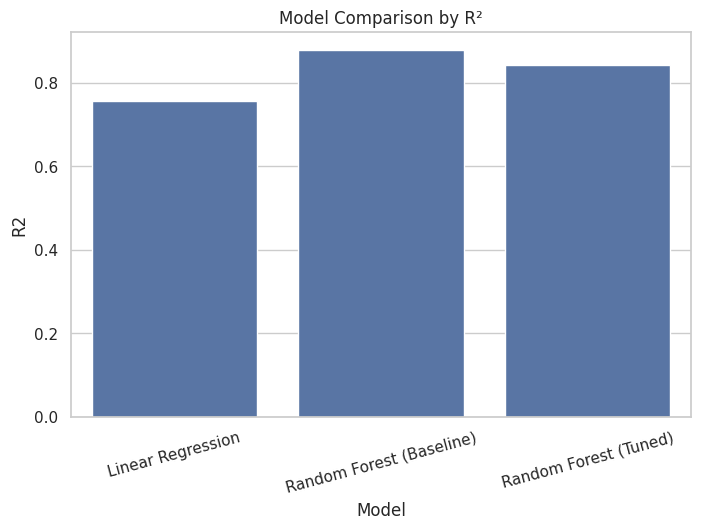%0A)

The Random Forest model outperformes the Linear Regression model. The
baseline Random Forest is the strongest on key metrics.

In \[256\]:

    rf_feature_importance = pd.DataFrame({ # Creating DataFrame to store feature importance
        "Feature": X.columns, # Feature names
        "Importance": rf_baseline.feature_importances_ # Extracting importance scores from trained Random Forest model # Accessing the Random forest # Array of importance values
    }).sort_values("Importance", ascending=False) # Sort features so the most important ones appear at the top

    rf_feature_importance.head(10) # Display the top 10 most important features

Out\[256\]:

|     | Feature | Importance |
|-----|---------|------------|
| 11  | LSTAT   | 0.551633   |
| 5   | RM      | 0.228081   |
| 0   | CRIM    | 0.086215   |
| 7   | DIS     | 0.046004   |
| 4   | NOX     | 0.028052   |
| 6   | AGE     | 0.018921   |
| 9   | TAX     | 0.017616   |
| 10  | PTRATIO | 0.011999   |
| 2   | INDUS   | 0.005221   |
| 8   | RAD     | 0.004601   |



This shows which predictors are most important with the strongest
predictive model.

## Final Model<a href="#Final-Model" class="anchor-link">¶</a>

In \[257\]:

    lr_pipeline = Pipeline([ # Creating pipeline
        ("scaler", StandardScaler()), # Scaling all features
        ("model", LinearRegression()) # Applying linear regression for tuning
    ])

    lr_param_grid = { # Defining parameters
        "model__fit_intercept": [True, False] # Fit_intercept parameter
    }

    lr_search = GridSearchCV( # Initializing GridSearchCV
        estimator=lr_pipeline, # The pipeline to tune
        param_grid=lr_param_grid, # Parameters to test
        cv=5, # Using 5 fold cross-validation
        scoring="r2" # Evaluating performance with R^2
    )

    lr_search.fit(X_train, y_train) # Fitting to the grid search

    best_lr_model = lr_search.best_estimator_ # Returning the full pipeline with the best parameter

Prepares the Linear Regression model for fair comparison.

In \[258\]:

    comparison_df = pd.DataFrame({ # Creating a DataFrame to compare model performance metrics
        "Model": ["Linear Regression", "Random Forest (Baseline)"], # Model names
        "R2": [lr_r2, rf_r2], # Measures how much variance is explained in the model
        "RMSE": [lr_rmse, rf_rmse], # Penalizes large errors more heavily
        "MAE": [lr_mae, rf_mae], # Average absolute difference between predictions and acutal values
        "MAPE": [lr_mape, rf_mape] # Average percentage error
    })

    comparison_df

Out\[258\]:

|     | Model                    | R2       | RMSE     | MAE      | MAPE      |
|-----|--------------------------|----------|----------|----------|-----------|
| 0   | Linear Regression        | 0.756968 | 4.221665 | 2.524404 | 12.222929 |
| 1   | Random Forest (Baseline) | 0.877508 | 2.997138 | 2.020893 | 10.892284 |





Comparing R^2, RMSE, MAE, and MAPE to decide which model is best for
prediction and which for explaination. This suggests that Linear
Regression is better for explaination and the Baseline Random Forest is
best for prediction.

In \[259\]:

    plt.figure(figsize=(7,5)) # Creating figure specifying width and height
    sns.barplot(data=comparison_df, x="Model", y="R2") # Generating bar plot
    plt.title("Final Model Comparison by R²") # Creating title
    plt.show() # Rendering plot

![No description has been provided for this
image](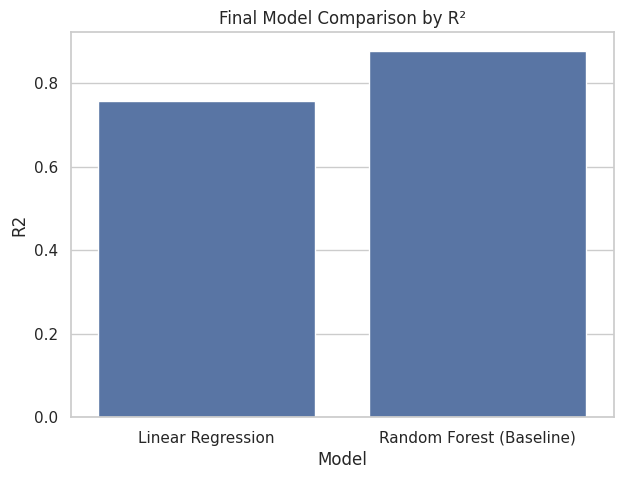%0A)

The visual comparition indicates the the Baseline Random Forest model
could explain more variance.

In \[260\]:

    final_models = { # Creating figure specifying width and height
        "Interpretation_Model": lr_final, # Linear regression model chosen for interpretation
        "Prediction_Model": rf_baseline, # Baseline Random Forest model chosen for prediction
        "Validated_Alternative": best_rf_model # Tuned Random Forest model kept as a validated alternative
    }

    print("Final Models Selected:") # Printing header
    print(final_models.keys()) # Printing model roles

    Final Models Selected:
    dict_keys(['Interpretation_Model', 'Prediction_Model', 'Validated_Alternative'])

This indicates the Linear Regression model helps to understand
diriection and the magnitude of predictor effects. The Baseline Random
Forest model performs best on R^2 and RMSE. The Tuned Random Forest
model is an optimized alternative.

In \[261\]:

    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    plt.scatter(y_test_actual, lr_pred_actual, alpha=0.7) # Creating scatter plot with actual and predicted values
    plt.plot( # Creating plot reference line
        [y_test_actual.min(), y_test_actual.max()], # x- coordinates
        [y_test_actual.min(), y_test_actual.max()], # y- coordinates
        linestyle="--" # Creating dash line
    )
    plt.title("Linear Regression: Actual vs Predicted") # Creating title
    plt.xlabel("Actual MEDV") # x- axis label
    plt.ylabel("Predicted MEDV") # y- axis label
    plt.show() # Rendering plot

![No description has been provided for this
image](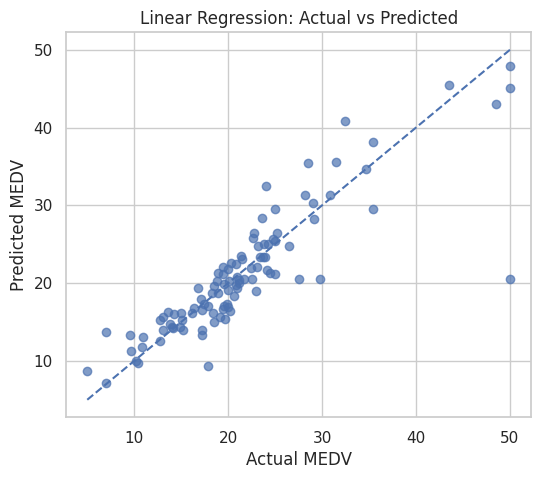%0A)

It appears the predictions from the Linear Regression model are accurate
with a positive trend.

In \[262\]:

    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    plt.scatter(y_test_actual, rf_pred_actual, alpha=0.7) # Scatter plot of actual versus predicted values
    plt.plot( # Plotting reference line
        [y_test_actual.min(), y_test_actual.max()], # x- coordinates
        [y_test_actual.min(), y_test_actual.max()], # y- coordinates
        linestyle="--" # Creating dash line
    )
    plt.title("Random Forest (Baseline): Actual vs Predicted") # Creating title
    plt.xlabel("Actual MEDV") # True values
    plt.ylabel("Predicted MEDV") # Model predictions
    plt.show() # Rendering plot

![No description has been provided for this
image](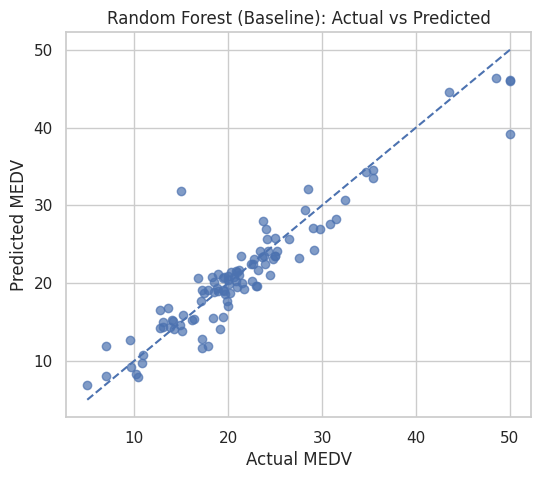%0A)

It appears the predictions from the Baseline Random Forest model are
accurate with a positive trend and tighter grouping.

In \[263\]:

    residuals_lr = y_test_actual - lr_pred_actual # Calculating residual errors for Linear Regression
    residuals_rf = y_test_actual - rf_pred_actual # Calculating residuals for Baseline Random Forest

    plt.figure(figsize=(6,4)) # Creating figure specifying width and height
    sns.histplot(residuals_lr, kde=True) # Creating histogram for residuals with a smooth density curve
    plt.title("Residual Distribution - Linear Regression") # Creating title
    plt.show() # Rendering plot

    plt.figure(figsize=(6,4)) # Creating figure specifying width and height
    sns.histplot(residuals_rf, kde=True) # Creating histogram for residuals with a smooth density curve
    plt.title("Residual Distribution - Random Forest (Baseline)") # Creating title
    plt.show() # Rendering plot

![No description has been provided for this
image](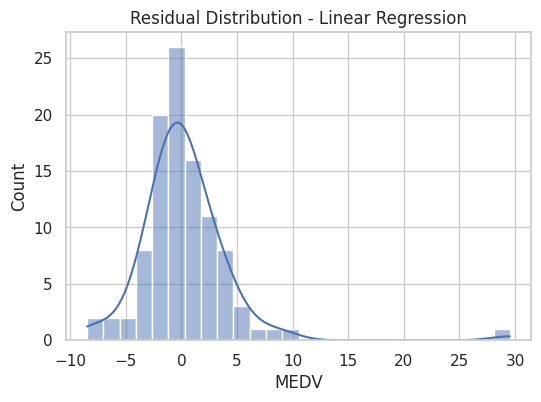%0A)

![No description has been provided for this
image](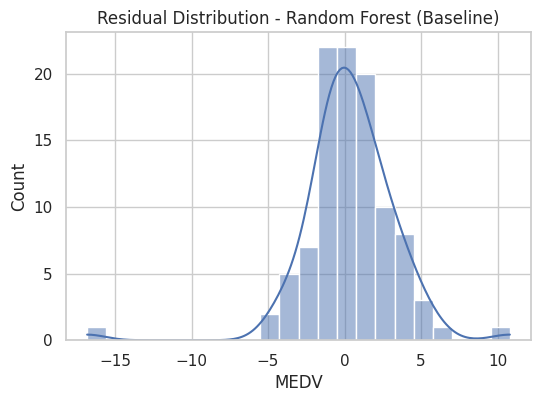%0A)

There is a tight distributions around zero indicating smaller and more
consistent errors. The Baseline Random Forrest model shows smaller
errors than the Linear Regression.

In \[264\]:

    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    plt.scatter(lr_pred_actual, residuals_lr, alpha=0.7) # Creating scatterplot of predicted values versus residuals
    plt.axhline(0, linestyle="--") # Creating dash line at 0
    plt.title("Linear Regression Residuals vs Predicted") # Creating title
    plt.xlabel("Predicted") # x- axis label
    plt.ylabel("Residuals") # y- axis label
    plt.show() # Rendering plot

    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    plt.scatter(rf_pred_actual, residuals_rf, alpha=0.7) # Creating scatterplot of predicted values versus residuals
    plt.axhline(0, linestyle="--") # Creating dash line at 0
    plt.title("Random Forest (Baseline) Residuals vs Predicted") # Creating title
    plt.xlabel("Predicted") # x- axis label
    plt.ylabel("Residuals") # y- axis label
    plt.show() # Rendering plot

![No description has been provided for this
image](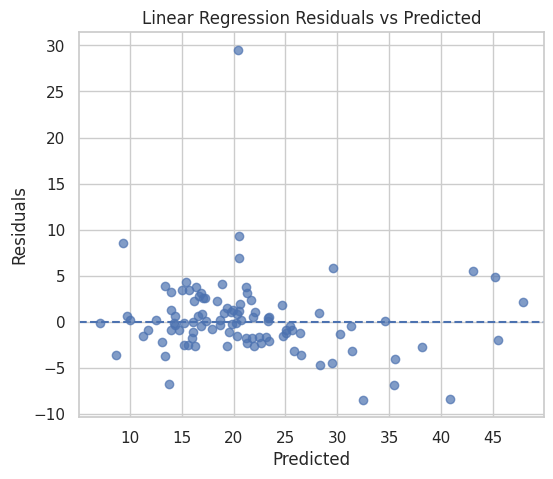%0A)

![No description has been provided for this
image](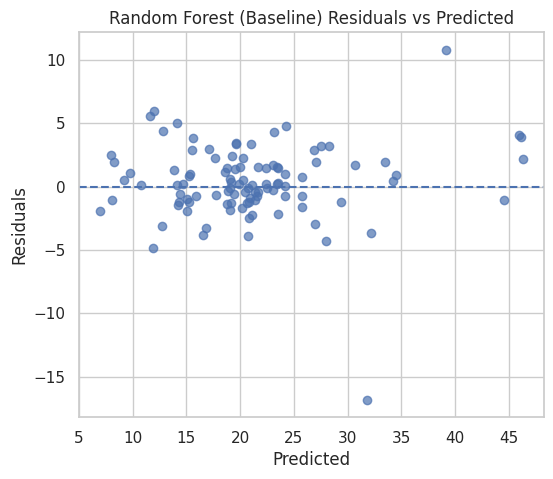%0A)

The Linear Regression model shows more structure and a wider spread
while the Baseline Random Forest model shows a more random and stable
pattern.

In \[265\]:

    error_df = pd.DataFrame({ # Creating a DataFrame comparing absolute prediction errors across models
        "Actual": y_test_actual, # Actual target values
        "LR_Error": abs(residuals_lr), # Absolute error for Linear Regression
        "RF_Error": abs(residuals_rf) # Absolute error for Baseline Random Forest
    })

    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    plt.scatter(error_df["Actual"], error_df["LR_Error"], label="Linear Regression", alpha=0.6) # Creating scatterplot for Linear Regression errors
    plt.scatter(error_df["Actual"], error_df["RF_Error"], label="Random Forest", alpha=0.6) # Creating scatterplot for Baseline Random Forest errors
    plt.legend() # Adding legend
    plt.title("Error Comparison by Actual Value") # Creating title
    plt.xlabel("Actual MEDV") # x- axis label
    plt.ylabel("Absolute Error") # y- axis label
    plt.show() # Rendering plot


    plt.figure(figsize=(6,5)) # Creating figure specifying width and height
    sns.regplot(x=error_df["Actual"], y=error_df["LR_Error"], scatter=False, label="LR Trend") # Plotting regression line for Linear Regression errors
    sns.regplot(x=error_df["Actual"], y=error_df["RF_Error"], scatter=False, label="RF Trend") # Plotting regression line for Baseline Random Forest errors
    plt.legend() # Adding legend
    plt.title("Error Trend by Model") # Creating title
    plt.xlabel("Actual MEDV") # x- axis label
    plt.ylabel("Absolute Error") # y- axis label
    plt.show() # Rendering plot

![No description has been provided for this
image](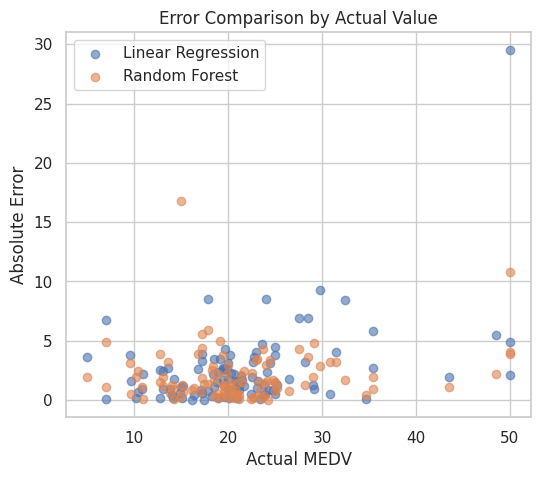%0A)

![No description has been provided for this
image](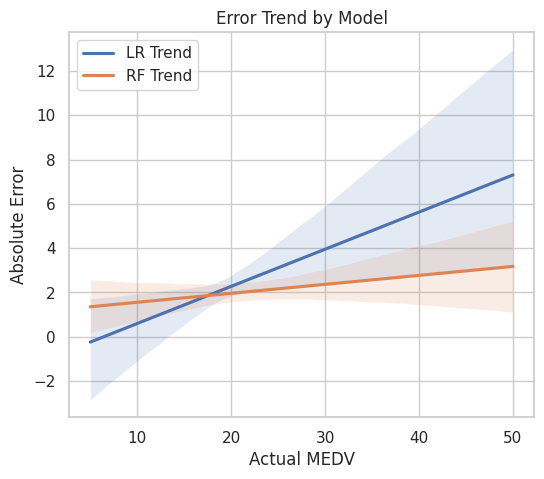%0A)

The Linear Regression model appears to struggle more with higher priced
homes than the Random Forest model. The Baseline Random Forest model
does better across the full price range.

## SHAP Explainability<a href="#SHAP-Explainability" class="anchor-link">¶</a>

In \[266\]:

    print("Model type:", type(rf_baseline)) # Confirming model

    explainer = shap.TreeExplainer(rf_baseline) # Creating SHAP explainer to fitted Random Forest
    shap_values = explainer.shap_values(X_test) # Computing SHAP values on test set

    shap.summary_plot(shap_values, X_test, plot_type="bar") # Global feature importance
    shap.summary_plot(shap_values, X_test) # Rendering summary plot

    shap.dependence_plot("RM", shap_values, X_test) # Dependence plot for RM
    shap.dependence_plot("LSTAT", shap_values, X_test) # Dependence plot for LSTAT

    shap.initjs() # Inisializing SHAP JavaScript visualization
    shap.force_plot( # Rendering force plot
        explainer.expected_value, # Base value
        shap_values[0], # SHAP values
        X_test.iloc[0] # Feature values
    )

    Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

![No description has been provided for this
image](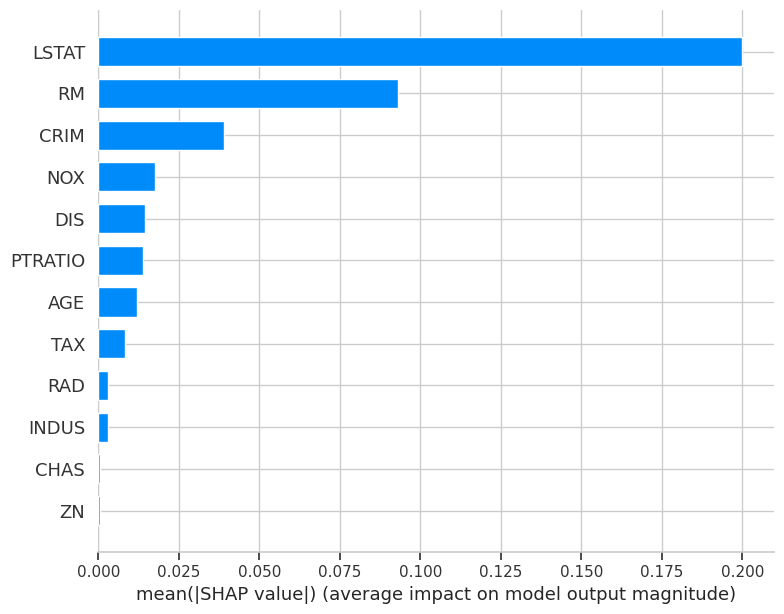%0A)

![No description has been provided for this
image](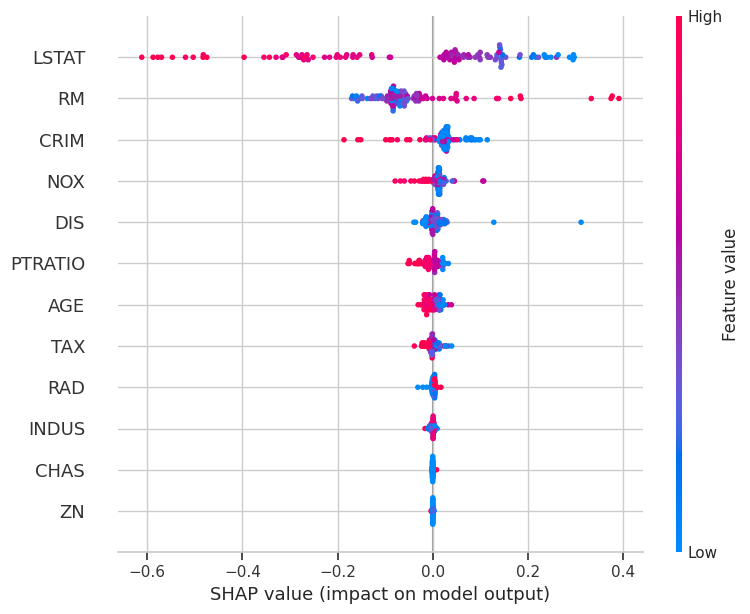%0A)

![No description has been provided for this
image](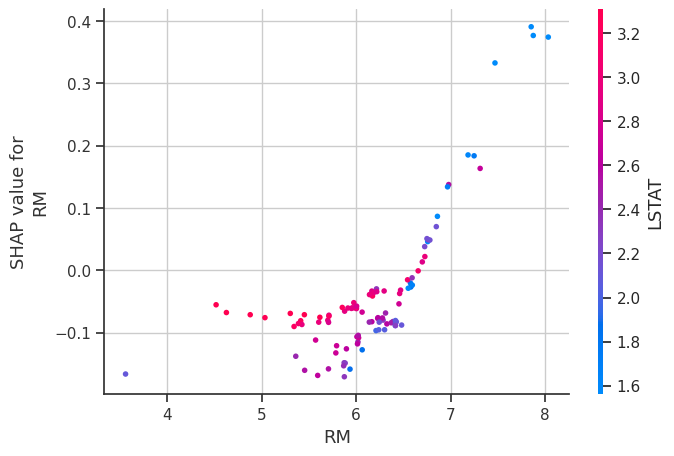%0A)

![No description has been provided for this
image](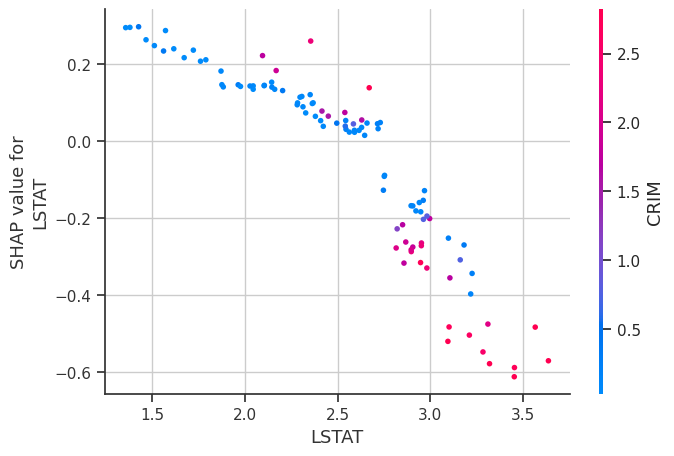%0A)

No description has been provided for this
image

Out\[266\]:

**Visualization omitted, Javascript library not loaded!**  
Have you run \`initjs()\` in this notebook? If this notebook was from
another user you must also trust this notebook (File -\> Trust
notebook). If you are viewing this notebook on github the Javascript has
been stripped for security. If you are using JupyterLab this error is
because a JupyterLab extension has not yet been written.

The model relies heavily on socioeconomic status LSTAT and room size RM
when predicting housing prices. This suggests that neihborhood
conditions and property characteristics are main drivers of value. The
summary plot confirms the higher the socioeconomic disadvantage
significantly lowers the predicted home values and more rooms increases
them. Enviromental and crime features also negatively impact
predictions. The dependency plot shows the model captures nonlinear
relationships, more noteable socioeconomic conditions. It shows a
positive effect with room size. The force plot shows there is a
complexity where in the prediction of home value is diverse and driven
by a combination of factors.

In \[267\]:

    best_model_row = comparison_df.loc[comparison_df["R2"].idxmax()] # Finding row corresponding to the highest R^2 Value
    print("Best predictive model by R²:", best_model_row["Model"]) # Printing the name of the best performing model

    Best predictive model by R²: Random Forest (Baseline)

Identifying the best predictive model as the Baseline Random Forest
model.

## Actionable Insights and Recommendations<a href="#Actionable-Insights-and-Recommendations"
class="anchor-link">¶</a>

## Executive Summary<a href="#Executive-Summary" class="anchor-link">¶</a>

This analysis project examines to what extent housing prices can be
predicted by structural, environmental, and socioeconomic factors. The
primary objective was to identify key drivers of home value and find the
optimal model for interpretation and prediction. The exploratory
analysis showed that housing prices are strongly influenced by
structural (RM) and socioeconomic (LSTAT) factors, with structural
factors having a positive impact and low socioeconomic status having a
negative impact. Other contributing factors include environmental or
neighborhood variables such as pollution levels (NOX), crime (CRIM), and
school quality (PTRATIO).

A Linear Regression model was utilized for interpretation.
Cross-validation showed that the model had difficulty capturing the
complexity of the data. This led to the utilization of a Random Forest
model to better capture that complexity. The baseline Random Forest
model was compared with a tuned Random Forest model, and the baseline
model appeared to perform better in terms of overall fit (R²) and error
magnitude (RMSE). The baseline Random Forest model was therefore chosen
as the predictive model.

The findings show that there is a complex interplay of factors that
impact housing prices. SHAP was applied to the Random Forest model to
assist in interpretability. The SHAP analysis confirmed socioeconomic
conditions and room size are the most influential factors.

## Actionable Insights<a href="#Actionable-Insights" class="anchor-link">¶</a>

1.  Property size is the strongest value driver

    -The number of rooms (RM) is the strongest indicator of home value.

2.  Socioeconomic conditions have a significant impact on home value

    -Lower socioeconomic status (LSTAT) is associated with lower home
    values.

3.  Environmental and neighborhood quality affect value

    -Higher pollution (NOX), crime (CRIM), and tax rates (TAX) are
    associated with lower home values.

4.  Education quality has an influence

    -A higher teacher-to-student ratio (PTRATIO) has a negative effect
    on home value.

5.  Prediction accuracy varies across price levels

    -The Linear Regression model shows more errors at higher home
    values, while the Random Forest model is more consistent across the
    full range of values.

6.  Model selection impacts decision quality

    -The baseline Random Forest model provides more accurate
    predictions, while the Linear Regression model is used for
    interpretability.

## Recommendations<a href="#Recommendations" class="anchor-link">¶</a>

1.  Prioritize property size

    -Particularly the number of rooms (RM).

2.  Target emerging neighborhoods

    -Look for neighborhoods with improving socioeconomic conditions
    (LSTAT).

3.  Target neighborhoods with improving environmental and community
    conditions

    -Look for neighborhoods with initiatives to improve air quality,
    public safety, and maintain a balanced tax structure.

4.  Target neighborhoods with educational investment

    -Look for neighborhoods with initiatives to improve educational
    infrastructure and reduce class sizes.

5.  Explore future models

    -Explore Gradient Boosting or XGBoost

## HTML Export<a href="#HTML-Export" class="anchor-link">¶</a>

In \[268\]:

    notebook_path = "/content/drive/MyDrive/Learners_Notebook_Boston_house_price_Full_Code_Working (5).ipynb"
    output_name = "Boston_Housing_Analysis_Predictive_Model"

    subprocess.run(
        [
            "jupyter",
            "nbconvert",
            "--to",
            "html",
            "--output",
            output_name,
            notebook_path,
        ],
        check=True,
    )

    print(f"Notebook exported as {output_name}.html")

    Notebook exported as Boston_Housing_Analysis_Predictive_Model.html

------------------------------------------------------------------------